# 02. Logistic regression, derived

**What changes from linear regression:** the target $y$ is 0 or 1 instead of a number, so the
model needs to output a probability, and the loss has to score probabilities instead of distances.
Everything else (weights, gradient, descent) is the same machinery.

| symbol | code name | what it is |
|---|---|---|
| $y_i \in \{0, 1\}$ | `y` | the class label: 1 = positive (malignant, fraud), 0 = negative |
| $z_i$ | `z` | the **logit** or linear score: $x_i \cdot w + b$. Any real number |
| $\sigma(z)$ | `sigmoid(z)` | the sigmoid function: squashes any number into $(0, 1)$ |
| $p_i = \hat{y}_i$ | `p` | the model's probability that row $i$ is class 1 |
| $L$ | `log_loss` | the loss: average negative log-likelihood |

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DB = "C:/Users/palla/OneDrive/Documents/Coding Projects/cheatsheets_and_templates/Homework/homework.sqlite"
con = sqlite3.connect(DB)
def q(sql):
    """Run SQL against homework.sqlite and return a DataFrame."""
    return pd.read_sql(sql, con)

SEED = 42
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#9a9a94"

## 1. The model: a line, then a squash

Start with the same linear score as before, now called the **logit**:

$$z_i = x_i \cdot w + b$$

$z$ can be any number, but a probability must sit between 0 and 1. The **sigmoid** does the squashing:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \qquad\qquad p_i = \sigma(z_i) = P(y_i = 1 \mid x_i)$$

Properties worth knowing by heart: $\sigma(0) = 0.5$, $\sigma(z) \to 1$ as $z \to +\infty$,
$\sigma(z) \to 0$ as $z \to -\infty$, and $\sigma(-z) = 1 - \sigma(z)$.

Undo the squash and you get the **log-odds**: $\ln\frac{p}{1-p} = z = x \cdot w + b$.
So a weight $w_j$ reads as "a one-unit increase in feature $j$ adds $w_j$ to the log-odds,"
or equivalently multiplies the odds by $e^{w_j}$.

**What this cell does:** implements the sigmoid and draws it.

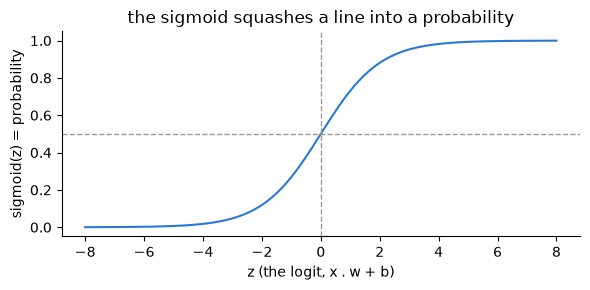

sigmoid(0) = 0.5    sigmoid(4) = 0.982    sigmoid(-4) = 0.018


In [2]:
def sigmoid(z):
    """sigma(z) = 1 / (1 + e^-z).  Maps any real number to (0, 1)."""
    return 1.0 / (1.0 + np.exp(-z))

def predict_probability(X, w, b):
    """p = sigmoid(X w + b): one probability per row."""
    return sigmoid(X @ w + b)

z_grid = np.linspace(-8, 8, 200)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(z_grid, sigmoid(z_grid), color=BLUE)
ax.axhline(0.5, color=GRAY, ls="--", lw=1); ax.axvline(0, color=GRAY, ls="--", lw=1)
ax.set(xlabel="z (the logit, x . w + b)", ylabel="sigmoid(z) = probability", title="the sigmoid squashes a line into a probability")
plt.tight_layout(); plt.show()
print("sigmoid(0) =", sigmoid(0), "   sigmoid(4) =", round(sigmoid(4), 4), "   sigmoid(-4) =", round(sigmoid(-4), 4))

## 2. The loss: log loss, from "how likely is the data?"

Squared error does not fit probabilities well. Instead, ask: given the model's probabilities,
how likely was the data we actually observed?

For one row, the model says class 1 with probability $p_i$. If the truth is $y_i = 1$, the
probability the model assigned to the truth is $p_i$. If $y_i = 0$, it is $1 - p_i$. One
expression covers both cases (one of the two exponents is always zero):

$$P(y_i \mid x_i) = p_i^{\,y_i}\,(1 - p_i)^{\,1 - y_i}$$

The likelihood of the whole dataset is the product over rows. Products of small numbers
underflow, so take the log, which turns the product into a sum. Flip the sign so that smaller
is better, and average:

$$L(w, b) = -\frac{1}{n}\sum_{i=1}^{n}\Big[\,y_i \ln p_i + (1 - y_i)\ln(1 - p_i)\,\Big]$$

This is **log loss** (also called binary cross-entropy). Read it row by row: if $y_i = 1$ the
row costs $-\ln p_i$, which is near 0 when $p_i$ is near 1 and huge when $p_i$ is near 0.
Confident and wrong is punished hard.

**What this cell does:** implements log loss and shows the cost of a few individual predictions.

In [3]:
def log_loss(y, p, epsilon=1e-12):
    """L = -(1/n) sum[ y ln p + (1-y) ln(1-p) ].  epsilon keeps ln(0) from happening."""
    p = np.clip(p, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

for truth, prob in [(1, 0.99), (1, 0.6), (1, 0.01), (0, 0.01), (0, 0.99)]:
    print(f"truth {truth}, predicted p = {prob:4.2f}  ->  cost {log_loss(np.array([truth]), np.array([prob])):.3f}")

truth 1, predicted p = 0.99  ->  cost 0.010
truth 1, predicted p = 0.60  ->  cost 0.511
truth 1, predicted p = 0.01  ->  cost 4.605
truth 0, predicted p = 0.01  ->  cost 0.010
truth 0, predicted p = 0.99  ->  cost 4.605


## 3. The gradient, and a pleasant surprise

Differentiate $L$ with respect to $w_j$. It takes three chain-rule steps (loss through $\ln$,
through $\sigma$, through $z$), and the derivative of the sigmoid is $\sigma'(z) = \sigma(z)(1 - \sigma(z))$.
The $p(1-p)$ from the sigmoid cancels against the $\frac{1}{p(1-p)}$ from the log, and what is left is:

$$\frac{\partial L}{\partial w_j} = \frac{1}{n}\sum_{i=1}^{n} (p_i - y_i)\,x_{ij}
\qquad\qquad
\nabla_w L = \frac{1}{n}X^{\top}(p - y)
\qquad
\frac{\partial L}{\partial b} = \frac{1}{n}\sum_i (p_i - y_i)$$

Compare to linear regression's $\nabla_w L = -\frac{2}{n}X^{\top}(y - \hat{y})$. Same shape:
"features times residual," where the residual is now $p - y$, the gap between the predicted
probability and the 0/1 truth. That is why both models train with the identical loop.

**What this cell does:** implements the gradient, verifies it numerically, and runs gradient descent
on the breast cancer table.

slope for w_0:  numerical -0.350797   derived -0.350798


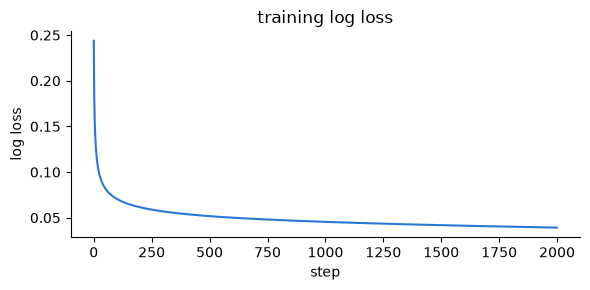

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

cancer = q("SELECT * FROM breast_cancer")
feature_names = [c for c in cancer.columns if c != "malignant"]
X_raw = cancer[feature_names].to_numpy()
y = cancer["malignant"].to_numpy().astype(float)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.25, stratify=y, random_state=SEED)

# Standardize: gradient descent converges far better when features share a scale.
scaler = StandardScaler().fit(X_train_raw)
X_train, X_test = scaler.transform(X_train_raw), scaler.transform(X_test_raw)

def gradients(X, y, w, b):
    """grad_w = (1/n) X^T (p - y),  grad_b = (1/n) sum(p - y)"""
    n_rows = len(y)
    p = predict_probability(X, w, b)
    residual = p - y
    return (X.T @ residual) / n_rows, np.sum(residual) / n_rows

# Numerical check on one weight.
w_test, b_test, nudge = np.zeros(X_train.shape[1]), 0.0, 1e-6
w_nudged = w_test.copy(); w_nudged[0] += nudge
numerical = (log_loss(y_train, predict_probability(X_train, w_nudged, b_test)) -
             log_loss(y_train, predict_probability(X_train, w_test, b_test))) / nudge
print(f"slope for w_0:  numerical {numerical:.6f}   derived {gradients(X_train, y_train, w_test, b_test)[0][0]:.6f}")

# Gradient descent, same loop as linear regression.
w, b = np.zeros(X_train.shape[1]), 0.0
learning_rate, n_steps = 0.5, 2000
loss_history = []
for step in range(n_steps):
    grad_w, grad_b = gradients(X_train, y_train, w, b)
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b
    loss_history.append(log_loss(y_train, predict_probability(X_train, w, b)))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(loss_history, color=BLUE); ax.set(xlabel="step", ylabel="log loss", title="training log loss")
plt.tight_layout(); plt.show()

## 4. From probability to decision, and the check against scikit-learn

The model outputs $p_i$. A decision needs a **threshold** $t$: predict class 1 when $p_i \ge t$.
At $t = 0.5$ that is the same as $z_i \ge 0$. The threshold is a business choice, not part of the
model; the fraud notebooks replaced it with "take the top $k$."

**A trap worth seeing.** This dataset is almost perfectly separable: a line can split malignant from
benign with very few mistakes. When that happens, the unregularized optimum does not exist. Log loss
keeps falling as the weights grow, forever, because a bigger $w$ makes every correct prediction
more confident. A library solver run to convergence with the penalty switched off produces enormous
weights. Our gradient descent stopped after 2,000 steps, which quietly acts as regularization
("early stopping"). So the two weight vectors have very different sizes but point the same way.

**What this cell does:** compares the hand-fit weights to `LogisticRegression` with the penalty
effectively off, shows that the weight vectors are nearly parallel (cosine similarity close to 1)
even though their lengths differ by a factor of fifty, and compares test AUC.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

library_model = LogisticRegression(C=1e6, max_iter=5000).fit(X_train, y_train)
w_library = library_model.coef_[0]

p_test_hand = predict_probability(X_test, w, b)
p_test_library = library_model.predict_proba(X_test)[:, 1]

cosine_similarity = (w @ w_library) / (np.linalg.norm(w) * np.linalg.norm(w_library))
print(f"length of w   by hand {np.linalg.norm(w):7.2f}   sklearn {np.linalg.norm(w_library):7.2f}")
print(f"cosine similarity between the two weight vectors: {cosine_similarity:.3f}   (1.0 = same direction)")
print(f"test AUC      by hand {roc_auc_score(y_test, p_test_hand):.4f}   sklearn {roc_auc_score(y_test, p_test_library):.4f}")
print(f"test accuracy at threshold 0.5, by hand: {np.mean((p_test_hand >= 0.5) == y_test):.4f}")
print("\nSame direction, different length: the ranking (AUC) is nearly identical, the probabilities are not.")
print("This is why real logistic regression is almost always fit WITH a penalty (notebook 03).")

length of w   by hand    6.68   sklearn  550.31
cosine similarity between the two weight vectors: 0.912   (1.0 = same direction)
test AUC      by hand 0.9895   sklearn 0.9727
test accuracy at threshold 0.5, by hand: 0.9650

Same direction, different length: the ranking (AUC) is nearly identical, the probabilities are not.
This is why real logistic regression is almost always fit WITH a penalty (notebook 03).


## Summary

- **Model:** $p = \sigma(Xw + b)$. Weights act on the log-odds.
- **Loss:** log loss, the negative average log-likelihood of the observed labels.
- **Gradient:** $\frac{1}{n}X^{\top}(p - y)$. Same "features times residual" shape as linear regression.
- **Decision:** a threshold on $p$, chosen by the cost of each kind of mistake, or replaced by top-$k$.

In [6]:
con.close()